In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# File importing

In [2]:
og_df = pd.read_csv('heart.csv')

In [3]:
df = og_df
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

# EDA & Data Cleaning

In [5]:
df['cp'].value_counts()

cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64

In [6]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [78]:
df.duplicated().sum()

np.int64(723)

In [79]:
df = df.drop_duplicates()

<Axes: xlabel='Count', ylabel='age'>

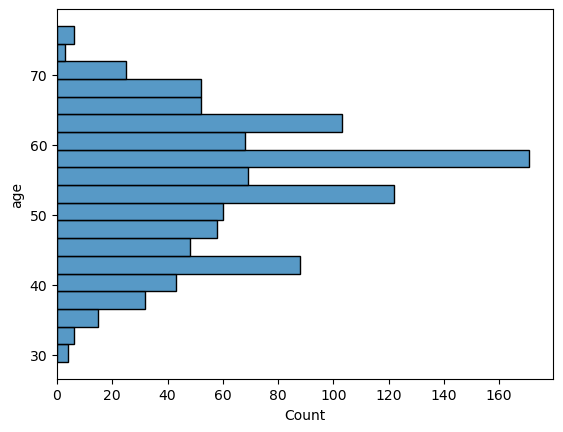

In [8]:
sns.histplot(y=df['age'])

<Axes: xlabel='age', ylabel='trestbps'>

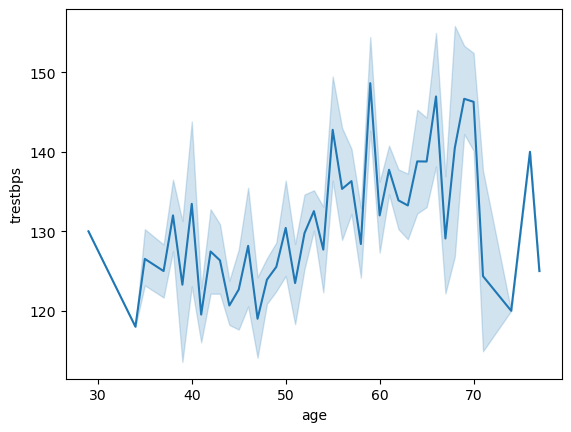

In [9]:
sns.lineplot(y = df['trestbps'], x = df['age'])

<Axes: xlabel='target', ylabel='trestbps'>

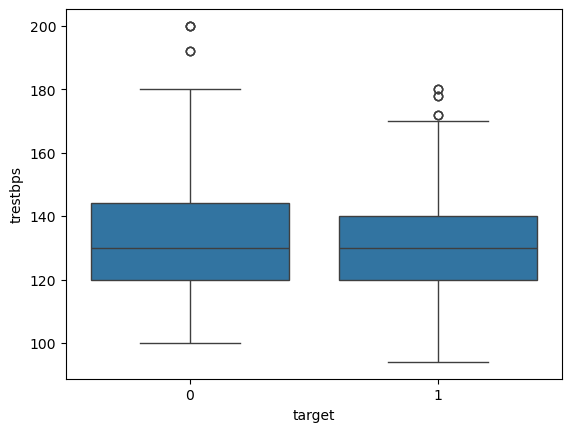

In [10]:
sns.boxplot(y = df['trestbps'], x = df['target'])

In [11]:
df['trestbps'].value_counts().sort_index()

trestbps
94       7
100     14
101      3
102      6
104      3
105      9
106      3
108     21
110     64
112     30
114      4
115      9
117      4
118     24
120    128
122     14
123      4
124     20
125     38
126     10
128     39
129      3
130    123
132     28
134     17
135     20
136     11
138     45
140    107
142      9
144      6
145     17
146      8
148      7
150     55
152     17
154      4
155      3
156      3
160     36
164      3
165      4
170     15
172      3
174      3
178      7
180     10
192      3
200      4
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='trestbps'>

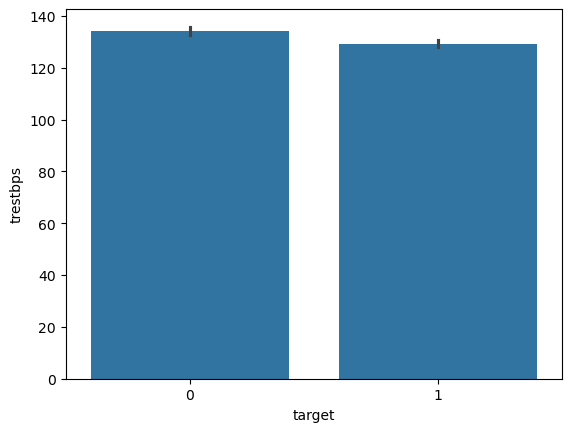

In [12]:
sns.barplot(y = df['trestbps'], x = df['target'])

<Axes: xlabel='Count', ylabel='trestbps'>

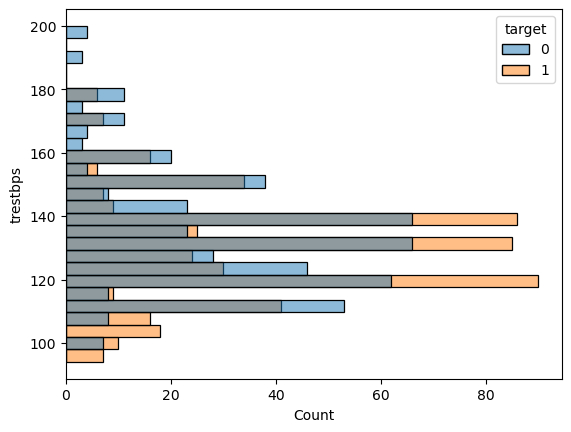

In [13]:
sns.histplot(y=df['trestbps'],hue=df['target'])

In [14]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<Axes: xlabel='chol', ylabel='Count'>

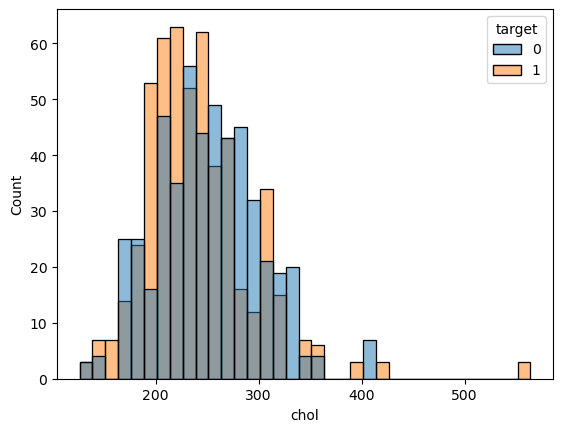

In [15]:
sns.histplot(x = df['chol'], hue = df['target'])

<Axes: xlabel='target', ylabel='chol'>

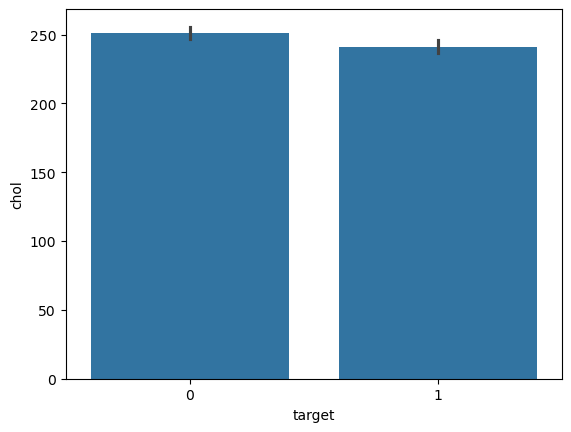

In [16]:
sns.barplot(x=df['target'], y = df['chol'])

<Axes: xlabel='target', ylabel='thalach'>

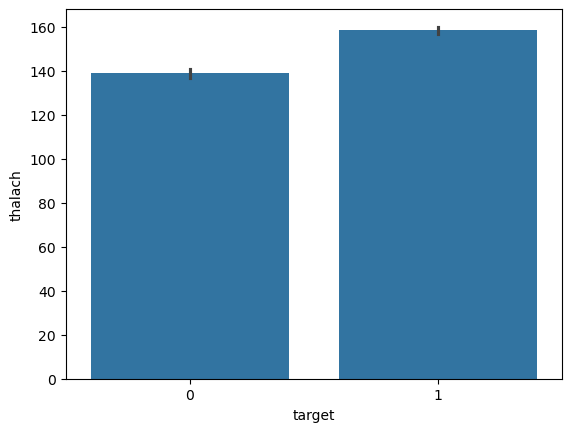

In [18]:
sns.barplot(x=df['target'], y = df['thalach'])

# Corellation graph

<Axes: >

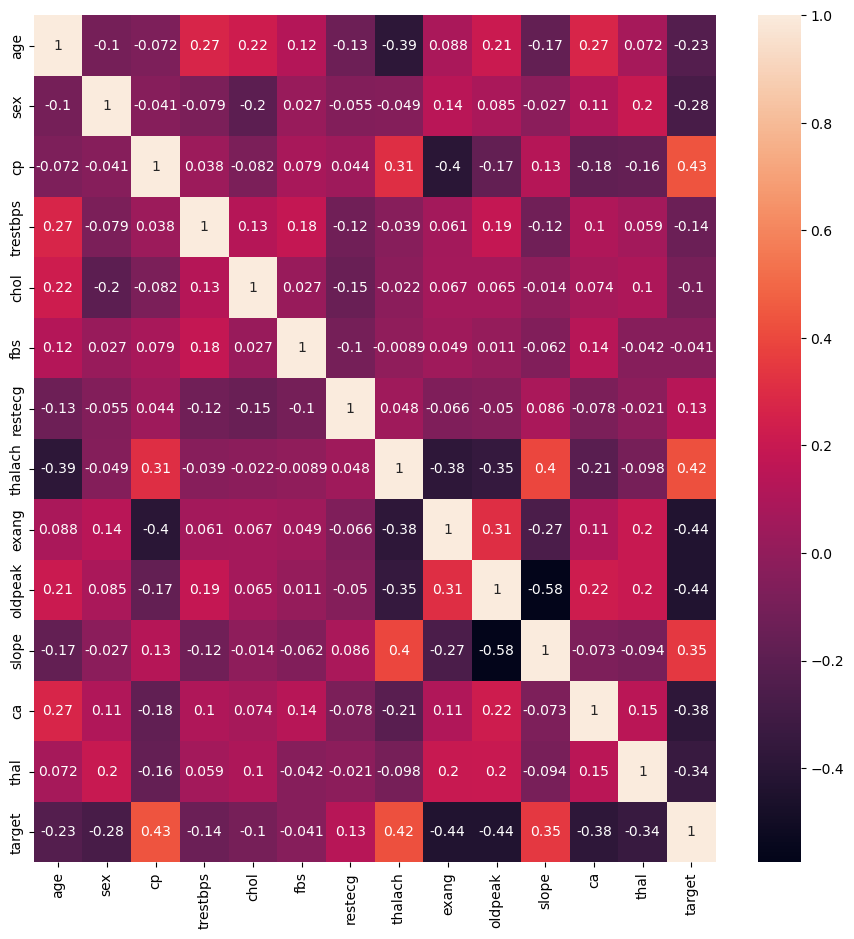

In [27]:
plt.figure(figsize=(11,11))
sns.heatmap(data = df.corr(), annot=True)


# One Hot Encoding

In [28]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [31]:
from sklearn.preprocessing import OneHotEncoder

In [37]:
encoder = OneHotEncoder(sparse_output=False)

In [43]:
encoded = encoder.fit_transform(df[['cp', 'restecg', 'slope', 'thal']])

In [45]:
encoded_df = pd.DataFrame(
    encoded,
    columns = encoder.get_feature_names_out(['cp', 'restecg', 'slope', 'thal'])
)
encoded_df

,cp_0,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1021,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1022,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1023,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [49]:
df = pd.concat([df, encoded_df], axis =1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,52,1,0,125,212,0,1,168,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,0,140,203,1,0,155,1,3.1,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,0,145,174,0,1,125,1,2.6,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,0,148,203,0,1,161,0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,0,138,294,1,1,106,0,1.9,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1021,60,1,0,125,258,0,0,141,1,2.8,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1022,47,1,0,110,275,0,0,118,1,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1023,50,0,0,110,254,0,0,159,0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [54]:
df.drop(columns = ['cp', 'restecg', 'slope', 'thal'], inplace=True)

In [55]:
df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,1,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,3,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,140,221,0,164,1,0.0,0,1,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1021,60,1,125,258,0,141,1,2.8,1,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1022,47,1,110,275,0,118,1,1.0,1,0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1023,50,0,110,254,0,159,0,0.0,0,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Standard Scalling

In [56]:
from sklearn.preprocessing import StandardScaler

In [57]:
scaler = StandardScaler()

In [107]:
df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak','ca']] = scaler.fit_transform(df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak','ca']])
df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,...,restecg_0,restecg_1,restecg_2,slope_0,slope_1,slope_2,thal_0,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0,0.806035,0,-0.037124,1.274980,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.157260,1,0.478910,-0.841918,1,0.237495,1,1.773958,-0.714911,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.724733,1,0.764066,-1.403197,0,-1.074521,1,1.342748,-0.714911,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.728383,1,0.935159,-0.841918,0,0.499898,0,-0.899544,0.280034,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.839089,0,0.364848,0.919336,1,-1.905464,0,0.739054,2.269926,0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,1.503322,0,-0.661712,-0.687083,0,-1.511859,0,0.394086,-0.714911,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
733,-1.153610,0,-1.346085,-2.041893,0,1.112172,0,-0.382092,-0.714911,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
739,-0.267966,1,-0.205463,0.164513,0,0.499898,1,-0.899544,0.280034,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
843,0.506972,1,1.619532,0.512893,0,-1.074521,0,-0.899544,-0.714911,0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Splitting Data set into X and y

In [108]:
X = df.drop('target', axis=1)
y = df['target']

# Train Test Splitting

In [109]:
from sklearn.model_selection import train_test_split

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Training on All Models & Evaluation

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report

In [112]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

In [113]:
result = []

for name, model in models.items():
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred, 
        output_dict=True,
    )

    result.append(
        {
            'Model' : name,
            'Accuracy' : report["accuracy"],
            "Precision": report["weighted avg"]["precision"],
            "Recall": report["weighted avg"]["recall"],
            "F1-Score": report["weighted avg"]["f1-score"]
        }
    )


In [114]:
result_df = pd.DataFrame(result)
result_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.737705,0.749703,0.737705,0.736433
1,KNN,0.786885,0.790701,0.786885,0.786885
2,Decision Tree,0.704918,0.715943,0.704918,0.703487
3,SVM,0.819672,0.823647,0.819672,0.819672


# Exporting Best Model

In [115]:
import joblib


In [116]:
joblib.dump(models['KNN'],'Heart_Model.pkl')

['Heart_Model.pkl']

In [117]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [118]:
print(X.columns.tolist())

['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2', 'thal_0', 'thal_1', 'thal_2', 'thal_3']
